### Test Retrieving One Sample

In [1]:
import numpy as np
from pathlib import Path
from src.gesture import Gesture

processed_train_dir = Path("data/processed_train/")

sample = np.load(processed_train_dir / "beat3_01.npz", allow_pickle=False)
print(sample.files)
print(sample["O"].shape, sample["O"].dtype, sample["O"].min(), sample["O"].max())
print(Gesture(sample["gesture"]).name)

['O', 'gesture', 'ts', 'id', 'num_clusters']
(2220,) int32 0 86
BEAT3


### Aggregate Processed Data

In [2]:
from src.load_seqs_by_label import load_seqs_by_label
from pathlib import Path # importing it again to keep my cells as independent as possible 

processed_train_dir = Path("data/processed_train/")
seqs_by_label = load_seqs_by_label(processed_train_dir)
for label, seqs in seqs_by_label.items():
    lens = [len(s) for s in seqs]
    print(label, len(seqs), "average sequence length (T):", sum(lens)/len(lens)) # T notation for length of sequence from Lec8_HMM.pdf slide 32

4 5 average sequence length (T): 2686.2
5 5 average sequence length (T): 2806.8
3 5 average sequence length (T): 2125.4
2 5 average sequence length (T): 2860.2
1 5 average sequence length (T): 2483.4
0 5 average sequence length (T): 2906.0


### Initialize HMM

In [6]:
%%capture cap

from src.HMM.HMM import HMM

num_states = 10
num_clusters = 100 
max_iters = 10

models = {}
loglikelihoods = {}

for label, seqs in seqs_by_label.items():
    hmm = HMM(N=num_states, M=num_clusters, init="random")
    loglikelihood_list = []

    print(f"Now training HMM for {label}")
    for epoch in range(10):
        ll, termination_prob = hmm.fit_once(seqs)
        print(f"Epoch {epoch} complete. Log-likelihood = {ll}, Final P(seq|model) = {termination_prob}.")
        loglikelihood_list.append(ll)
    
    models[label] = hmm
    loglikelihoods[label] = loglikelihood_list

# use this to save the printed output to a txt file. Source: https://saturncloud.io/blog/how-to-save-the-output-of-a-cell-as-a-text-file-in-jupyter-notebook/
with open('outputs/training_logs/HMMs.txt', 'w+') as file:
    file.write(cap.stdout)

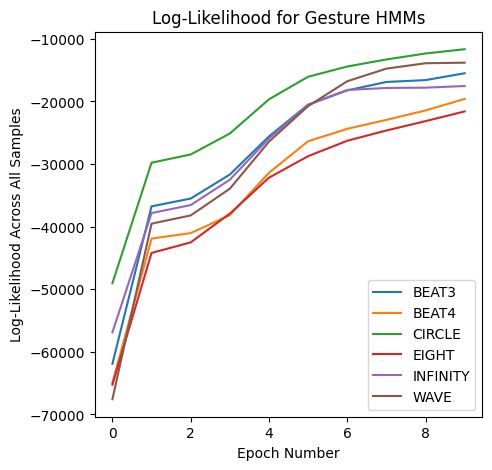

In [7]:
import matplotlib.pyplot as plt
from src.gesture import Gesture
fig, ax = plt.subplots(1,1, figsize=(5,5))
for label, ll in loglikelihoods.items():
    ax.plot(range(len(ll)), ll, label=Gesture(label).name)

ax.set_xlabel("Epoch Number")
ax.set_ylabel("Log-Likelihood Across All Samples")
ax.set_title("Log-Likelihood for Gesture HMMs")
ax.legend()

plt.savefig("outputs/figures/loglikelihood", bbox_inches='tight')
plt.show()

In [8]:
# determine the accuracy on the training set
# classify each sequence and see if it matches the label given

from src.HMM.classify import classify 

for label, seqs in seqs_by_label.items():
    for seq in seqs:
        classify(seq, models)
        

TypeError: object of type 'numpy.int32' has no len()